# MidiTranslator — decoder-only seq2seq2 translator, model validation

Loads `configs/midi-translator-seq2seq2.yaml` and validates `MidiTranslator` / `MidiTranslatorLoss`
against the `Seq2Seq2` batch. What separates this model from its siblings in `starry/midi/models/`
(`midiBgptTrans`, `midiSeq2BgptSelfAttn`, `midiSeq2PrefixInTokenLevel`) is that there is **no patch
dimension, no cross-attention and no second vocabulary**: the feeder hands over one flat id sequence

```
<bos>? source...  <sep>  <bos>? target... <eos>
```

so a single causal stack over the shared 838-token midiseq2 vocabulary does the whole job. The source
half is context only — never a target.

That makes the **shift geometry** the one thing that has to be exactly right, and it is what most of
this notebook is about: `logits[:, i - 1]` is compared against `input_ids[:, i]` wherever
`target_mask` is 1, which puts `<sep>` at the last context position before the first supervised
token. Off by one in either direction and the model is either predicting the source (leakage) or
skipping the target's first token (a silent hole) — neither shows up in the loss curve, so both are
checked directly here.

Sections:
1. Load the config, a batch, and a small CPU model
2. Batch geometry — what the feeder actually hands over
   (2b. `pos_style`: the three RoPE position conventions)
3. The shift, checked on a hand-built row where every position is identifiable
4. Causality and conditioning — no future leak, but the source *does* matter
   (4a. the applied attention mask, recovered by perturbation)
5. Padding invariance
6. Loss, metrics, `stat()` folding, per-token-type errors
7. Overfit one batch
8. Free-run generation from a real source half

In [1]:
%matplotlib inline
from pathlib import Path
import os
import sys

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.utils.data as tud

from starry.utils.config import Configuration
from starry.utils.dataset_factory import loadDataset
from starry.utils.model_factory import loadModel
from starry.utils.weightedValue import WeightedValue
from starry.midi.data.seq2seq2 import Seq2Seq2

CONFIG = str(REPO_ROOT / 'configs' / 'midi-translator-seq2seq2.yaml')
DATA_DIR = os.environ['DATA_DIR']
torch.manual_seed(0)

# Okabe-Ito, consistent with the other notebooks in this directory.
C_SRC, C_TGT = '#0072B2', '#D55E00'

## 1. Load the config, a batch, and a small CPU model

The data block is read exactly as the trainer reads it; only `batch_size` and the model size are
shrunk so this runs on CPU in seconds. `random_crop=False` on the val arm means a re-run inspects
the same sample.

`loadModel(config['model'], postfix='Loss')` is the trainer's own call — the config says
`type: MidiTranslator` and what comes back is `MidiTranslatorLoss`. That postfix is not cosmetic:
it is the only thing tying the config name to the registered class, and a mismatch surfaces as
`RuntimeError: Model type ...Loss not found`.

In [2]:
config = Configuration.createOrLoad(CONFIG, volatile=True)

print('pairing   :', config['data.args.source_dir'], '->', config['data.args.target_dir'])
print('mark_mode :', config['data.args.mark_mode'], '| line_range:', config['data.args.line_range'])
print('data root :', Path(DATA_DIR) / config['data.root'])
print('model     :', config['model.type'], '| backbone:', config['model.args.backbone'])

train_loader, val_loader = loadDataset(config, data_dir=DATA_DIR, device='cpu')
train, val = train_loader.dataset, val_loader.dataset
print('samples   : train', len(train), '| val', len(val))

BS = 3
loader = tud.DataLoader(val, batch_size=BS, collate_fn=val.collateBatch)
batch = next(iter(loader))

# A small CPU model: same architecture, fewer dims, so every check below runs fast. The production
# size (d_model 512 / 8 layers = 34.4M params) is in the config.
small = dict(config['model.args'])
small.update(d_model=128, n_layer=2, n_head=4)
model = loadModel({'type': config['model.type'], 'args': small},
    postfix='Loss', imports=config['imports'])
print('\nloadModel ->', type(model).__name__, '| deducer:', type(model.deducer).__name__)
print('params    : %.2fM (small) | vocab %d' % (
    sum(p.numel() for p in model.parameters()) / 1e6, model.deducer.vocab_size))

pairing   : midi-seq2-irregular -> midi-seq2-score
mark_mode : tick | line_range: [20, 256]
data root : /home/camus/data/midi/test202608
model     : MidiTranslator | backbone: llama
samples   : train 90 | val 9

loadModel -> MidiTranslatorLoss | deducer: MidiTranslator
params    : 0.74M (small) | vocab 838


## 2. Batch geometry

Four tensors, and the invariants that make the loss well-defined: `target_mask` must be a strict
subset of `masks` (never supervise padding), must start exactly one past `<sep>`, and must never
touch the source half.

Note how uneven the target lengths are — the crop cap is drawn per sample from `line_range`, so a
batch mixes short and long targets. That is why `acc` is reported as a `WeightedValue` over the
supervised-token count rather than a per-batch mean: a plain mean would let a 13-token target count
as much as a 300-token one.

In [3]:
ids, masks, tmask, sep = (batch['input_ids'], batch['masks'], batch['target_mask'], batch['sep_index'])
posn = batch['position_ids']   # RoPE positions, see 2b
tok = val.tokenizer
print('shapes:', {k: tuple(v.shape) for k, v in batch.items()})
print()

for r in range(len(ids)):
    n = int(masks[r].sum())
    s = int(sep[r])
    first = int(tmask[r].nonzero()[0]) if tmask[r].any() else -1
    last = int(tmask[r].nonzero()[-1])
    print('row %d  len %4d  sep %4d  source %4d  target %4d  | tmask [%d..%d]  last id %s' % (
        r, n, s, s, int(tmask[r].sum()), first, last, tok.tokens[int(ids[r, n - 1])]))

checks = [
    ('target_mask subset of masks', bool(((tmask == 1) <= (masks == 1)).all())),
    ('target starts one past <sep>', all(int(tmask[r].nonzero()[0]) == int(sep[r]) + 1 for r in range(len(ids)))),
    ('nothing supervised at or before <sep>', all(tmask[r, :int(sep[r]) + 1].sum() == 0 for r in range(len(ids)))),
    ('<sep> id sits at sep_index', all(int(ids[r, int(sep[r])]) == tok.sep_id for r in range(len(ids)))),
    ('exactly one <sep> per row', all(int((ids[r] == tok.sep_id).sum()) == 1 for r in range(len(ids)))),
    ('target ends with <eos>', all(int(ids[r, int(masks[r].sum()) - 1]) == tok.eos_id for r in range(len(ids)))),
    ('no <eos> in the source half', all(int((ids[r, :int(sep[r])] == tok.eos_id).sum()) == 0 for r in range(len(ids)))),
    ('no <unknown> anywhere', int((ids == tok.unknown_id).sum()) == 0),
]
print()
for name, ok in checks:
    print(('  OK   ' if ok else '  FAIL ') + name)
assert all(ok for _, ok in checks)

shapes: {'input_ids': (3, 874), 'masks': (3, 874), 'target_mask': (3, 874), 'sep_index': (3,), 'position_ids': (3, 874)}

row 0  len  142  sep   93  source   93  target   48  | tmask [94..141]  last id <eos>
row 1  len  581  sep  358  source  358  target  222  | tmask [359..580]  last id <eos>
row 2  len  874  sep  629  source  629  target  244  | tmask [630..873]  last id <eos>

  OK   target_mask subset of masks
  OK   target starts one past <sep>
  OK   nothing supervised at or before <sep>
  OK   <sep> id sits at sep_index
  OK   exactly one <sep> per row
  OK   target ends with <eos>
  OK   no <eos> in the source half
  OK   no <unknown> anywhere


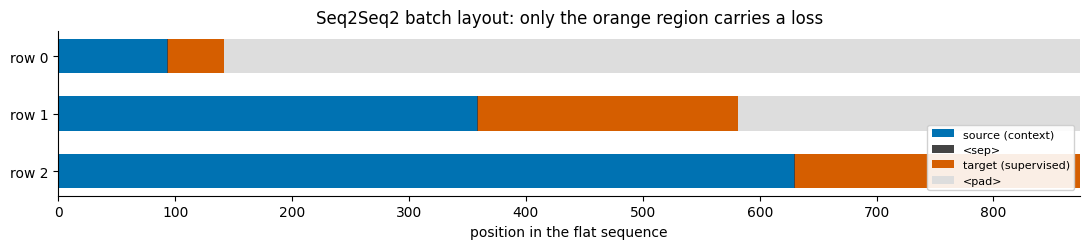

In [4]:
# The three regions of each row, drawn to scale: source context / <sep> / supervised target / padding.
fig, ax = plt.subplots(figsize=(11, 1.1 + 0.5 * len(ids)))
for r in range(len(ids)):
    n, s = int(masks[r].sum()), int(sep[r])
    ax.barh(r, s, color=C_SRC, height=0.6, label='source (context)' if r == 0 else None)
    ax.barh(r, 1, left=s, color='#444444', height=0.6, label='<sep>' if r == 0 else None)
    ax.barh(r, n - s - 1, left=s + 1, color=C_TGT, height=0.6, label='target (supervised)' if r == 0 else None)
    ax.barh(r, ids.shape[1] - n, left=n, color='#dddddd', height=0.6, label='<pad>' if r == 0 else None)
ax.set_yticks(range(len(ids)))
ax.set_yticklabels([f'row {r}' for r in range(len(ids))])
ax.set_xlabel('position in the flat sequence')
ax.set_title('Seq2Seq2 batch layout: only the orange region carries a loss')
ax.invert_yaxis()
ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

## 2b. `pos_style` — the RoPE position convention

The feeder emits `position_ids` alongside the ids, and `pos_style` picks the convention:

| style | source half | `<sep>` | target half |
|---|---|---|---|
| `flat` | `0 … s-1` | `s` | `s+1 … T-1` |
| `sep` | `… -3, -2` | `-1` | `0, 1, 2 …` |
| `absolute` | source FILE's last token is `-2`, counting down | `-1` | target FILE's first token is `0`, counting up |

`flat` and `sep` emit different numbers but are **equivalent to the model**: both are one arithmetic
run, and RoPE reads only relative distance, so shifting every position by a constant changes nothing.
`sep` buys readability — a position's sign tells you which half it is in. Only `absolute` changes
behaviour, since the gap it opens between the halves depends on where each crop sits in its file.

Why `absolute` is built this way rather than by adding a fixed offset to the source: it guarantees
source `<= -2` and target `>= -1`, so the halves can never share a position id nor invert their order,
however long the files get. A fixed offset cannot promise that once a file exceeds it — measured on
this corpus at `-N/2` (half the slowest RoPE period, 23559), 0.4% of crops collided and 1.25% came out
inverted, because the irregular arm reaches 76567 tokens while the score arm caps at 41416.

In [5]:
# All three styles, same sample: ids must be identical, only the positions differ.
from starry.midi.data.seq2seq2 import Seq2Seq2 as _S2

DATA_ROOT = str(Path(DATA_DIR) / config['data.root'])
style_sets = {}
for _style in ('flat', 'sep', 'absolute'):
    _args = dict(config['data.args']); _args.update(pos_style=_style, random_crop=False)
    style_sets[_style] = _S2.load(DATA_ROOT, _args, splits=config['data.splits'],
        args_variant=config['data.args_variant'])[1]

_idx = style_sets['flat'].indices[0]
cases = {k: ds.describe(_idx) for k, ds in style_sets.items()}
assert cases['flat']['ids'] == cases['sep']['ids'] == cases['absolute']['ids'], \
    'pos_style must not change the ids'
print('ids identical across all three styles: True')
print('config uses pos_style:', config['data.args.pos_style'])
print()

for _style, case in cases.items():
    pos, s_ = case['positions'], case['sep']
    print('%-9s source [%7d .. %7d]  <sep> %5d  target [%6d .. %6d]'
          % (_style, pos[0], pos[s_ - 1], pos[s_], pos[s_ + 1], pos[-1]))
print()
print('crop: head', cases['flat']['head'], '| tail', cases['flat']['tail'],
      '| source file tokens', cases['absolute']['source'].token_before[-1])

# The invariants that make 'absolute' collision-free.
_p, _s = cases['absolute']['positions'], cases['absolute']['sep']
print()
print("'absolute' invariants:")
print('  source all <= -2            :', max(_p[:_s]) <= -2)
print('  <sep> == -1                 :', _p[_s] == -1)
print('  target all >= -1            :', min(_p[_s + 1:]) >= -1)
print('  halves share no position    :', max(_p[:_s]) < min(x for x in _p[_s + 1:] if x >= 0))
assert max(_p[:_s]) <= -2 and _p[_s] == -1 and min(_p[_s + 1:]) >= -1

ids identical across all three styles: True
config uses pos_style: absolute

flat      source [      0 ..      92]  <sep>    93  target [    94 ..    141]
sep       source [    -94 ..      -2]  <sep>    -1  target [     0 ..     47]
absolute  source [ -17285 ..  -17193]  <sep>    -1  target [    -1 ..     46]

crop: head True | tail False | source file tokens 17283

'absolute' invariants:
  source all <= -2            : True
  <sep> == -1                 : True
  target all >= -1            : True
  halves share no position    : True


In [6]:
# flat vs sep must give identical model output; absolute must differ. Checked on ONE unpadded row,
# because a padded batch involves the pad tail's positions and would confound the comparison.
model.eval()
hidden = {}
for _style, ds in style_sets.items():
    _ids, _sep, _pos, _skip = ds._item(_idx)
    with torch.no_grad():
        hidden[_style] = model.deducer.backbone(
            input_ids=_ids.unsqueeze(0), position_ids=_pos.unsqueeze(0)).last_hidden_state

d_sep = (hidden['flat'] - hidden['sep']).abs().max().item()
d_abs = (hidden['flat'] - hidden['absolute']).abs().max().item()
print('flat vs sep       max|delta| %.3e  -> equivalent (RoPE is relative)' % d_sep)
print('flat vs absolute  max|delta| %.3e  -> genuinely different' % d_abs)
assert d_sep < 1e-4, 'flat and sep should be equivalent — a uniform shift is invisible to RoPE'
assert d_abs > 1e-3, 'absolute should change the model output'

# Padding must not disturb any of them: the pad tail CONTINUES each row's run rather than taking a
# constant fill. A constant would put a real position (0, which every style uses) on a pad slot and
# break the arithmetic run — measured at 4e-2 on the hidden states before this was fixed.
print()
for _style, ds in style_sets.items():
    _items = [ds[i] for i in range(3)]
    _b = ds.collateBatch(_items)
    _n = len(_items[0][0])
    _solo = {k: v[:1, :_n] for k, v in _b.items() if k != 'sep_index'}
    with torch.no_grad():
        _l_in, _ = model({k: v[:1] for k, v in _b.items() if k != 'sep_index'})
        _l_solo, _ = model(_solo)
    _tail_ok = int(_b['position_ids'][0, _n]) == int(_items[0][2][-1]) + 1
    print('%-9s row0 padded %.8f vs unpadded %.8f  delta %.1e | pad continues run: %s'
          % (_style, _l_in.item(), _l_solo.item(), abs(_l_in.item() - _l_solo.item()), _tail_ok))
    assert abs(_l_in.item() - _l_solo.item()) < 1e-5 and _tail_ok

flat vs sep       max|delta| 1.311e-06  -> equivalent (RoPE is relative)
flat vs absolute  max|delta| 1.445e-01  -> genuinely different

flat      row0 padded 6.83077431 vs unpadded 6.83077431  delta 0.0e+00 | pad continues run: True
sep       row0 padded 6.83077431 vs unpadded 6.83077431  delta 0.0e+00 | pad continues run: True
absolute  row0 padded 6.83084726 vs unpadded 6.83084726  delta 0.0e+00 | pad continues run: True


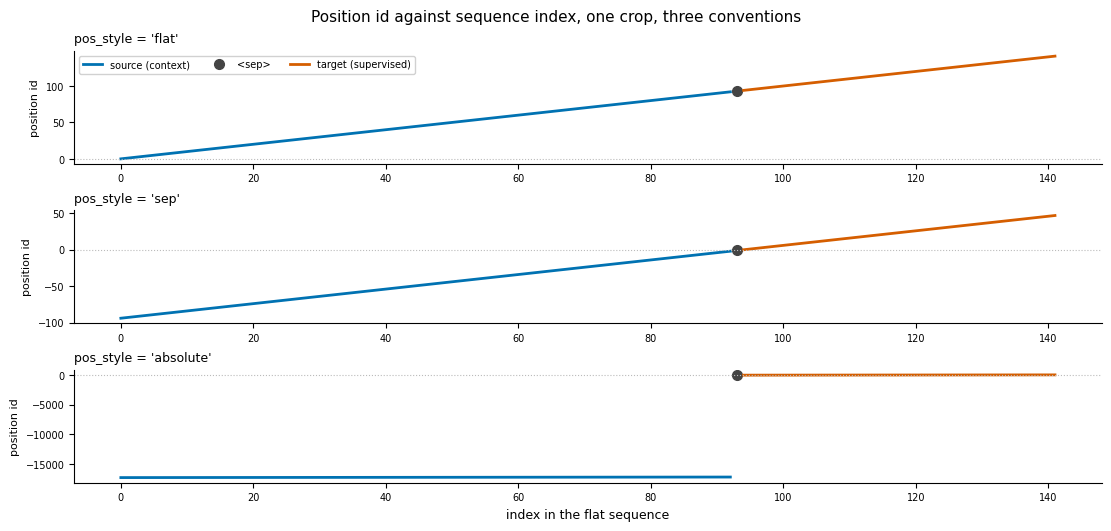

In [7]:
# The three conventions drawn on the same crop. Note the x scale differs per panel: that IS the point
# of 'absolute' -- its two halves sit thousands of tokens apart on their own files' axes.
fig, axes = plt.subplots(3, 1, figsize=(11, 5.2), layout='constrained')
for ax, (_style, case) in zip(axes, cases.items()):
    pos, s_ = case['positions'], case['sep']
    ax.plot(range(s_), pos[:s_], color=C_SRC, lw=2, label='source (context)')
    ax.plot([s_], [pos[s_]], 'o', color='#444444', ms=7, label='<sep>')
    ax.plot(range(s_ + 1, len(pos)), pos[s_ + 1:], color=C_TGT, lw=2, label='target (supervised)')
    ax.axhline(0, color='#bbbbbb', lw=0.8, ls=':')
    ax.set_ylabel('position id', fontsize=8)
    ax.set_title("pos_style = '%s'" % _style, fontsize=9, loc='left')
    ax.tick_params(labelsize=7)
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
axes[0].legend(fontsize=7, loc='upper left', ncol=3, framealpha=0.9)
axes[-1].set_xlabel('index in the flat sequence', fontsize=9)
fig.suptitle('Position id against sequence index, one crop, three conventions', fontsize=11)
plt.show()

## 3. The shift, on a row where every position is identifiable

`_shift` is the single place the loss geometry lives, so both the loss and every metric inherit it and
cannot disagree. To check it, feed a hand-built row and synthetic logits whose argmax at position `i`
is the unique value `i * 100`. Then the logits row actually used for each supervised label is readable
off the returned tensor.

Row: `[10, 11, <sep>, 20, 21, <eos>, <pad>, <pad>]` with the target region at positions 3-5.

What has to come out:
- labels `[20, 21, <eos>]` — the target tokens, `<eos>` included (it is a supervised stop signal)
- logits rows 2, 3, 4 — i.e. position 3 is predicted from position **2**, which is `<sep>`

The last point is the whole convention: `<sep>` is the last context position, so predicting the
target's first token is the model's first supervised act, and no source position is ever a label.

In [8]:
SEP, EOS, PAD = tok.sep_id, tok.eos_id, tok.pad_id
probe = dict(
    input_ids=torch.tensor([[10, 11, SEP, 20, 21, EOS, PAD, PAD]]),
    masks=torch.tensor([[1, 1, 1, 1, 1, 1, 0, 0]]),
    target_mask=torch.tensor([[0, 0, 0, 1, 1, 1, 0, 0]]),
)
T = probe['input_ids'].shape[1]

# Synthetic logits: argmax at position i is i * 100, so a returned row identifies where it came from.
fake = torch.full((1, T, model.deducer.vocab_size), -10.0)
for t in range(T):
    fake[0, t, t * 100] = 10.0

pred, labels = model._shift(probe, fake)
used_rows = (pred.argmax(dim=-1) // 100).tolist()

print('labels    :', labels.tolist(), '  (expect [20, 21, %d] — target tokens incl. <eos>)' % EOS)
print('logits row:', used_rows, '  (expect [2, 3, 4] — each target predicted from the position before)')
print('<sep> at   : 2  -> first supervised prediction comes from <sep>:', used_rows[0] == 2)
print()
print('%-4s %-10s %-16s %s' % ('pos', 'input', 'role', 'predicted from'))
for t in range(T):
    tid = int(probe['input_ids'][0, t])
    role = ('padding' if probe['masks'][0, t] == 0 else
            'SUPERVISED' if probe['target_mask'][0, t] == 1 else 'context')
    src = ('pos %d' % (t - 1)) if probe['target_mask'][0, t] == 1 else '-'
    print('%-4d %-10s %-16s %s' % (t, tok.tokens[tid], role, src))

assert labels.tolist() == [20, 21, EOS]
assert used_rows == [2, 3, 4], used_rows
print('\nshift geometry OK')

labels    : [20, 21, 2]   (expect [20, 21, 2] — target tokens incl. <eos>)
logits row: [2, 3, 4]   (expect [2, 3, 4] — each target predicted from the position before)
<sep> at   : 2  -> first supervised prediction comes from <sep>: True

pos  input      role             predicted from
0    set_tempo  context          -
1    time_signature context          -
2    <sep>      context          -
3    control_change SUPERVISED       pos 2
4    program_change SUPERVISED       pos 3
5    <eos>      SUPERVISED       pos 4
6    <pad>      padding          -
7    <pad>      padding          -

shift geometry OK


In [9]:
# The same check on the REAL batch: for every supervised position, the logits row is exactly one to
# its left, and the label is the token sitting there. Verified positionally rather than by trusting
# _shift's slicing, so an off-by-one anywhere in it fails here.
with torch.no_grad():
    logits = model.deducer(ids, masks)
pred_r, labels_r = model._shift(batch, logits)

expect_labels, expect_logits = [], []
for r in range(len(ids)):
    for t in range(ids.shape[1]):
        if tmask[r, t] == 1:
            expect_labels.append(int(ids[r, t]))
            expect_logits.append(logits[r, t - 1])

print('supervised positions      :', len(expect_labels), '| _shift returned:', int(labels_r.numel()))
print('labels match position-wise:', labels_r.tolist() == expect_labels)
print('logits match position-wise:', torch.allclose(pred_r, torch.stack(expect_logits)))
print('supervised count == tmask :', int(labels_r.numel()) == int(tmask.sum()))
assert labels_r.tolist() == expect_labels
assert torch.allclose(pred_r, torch.stack(expect_logits))
assert int(labels_r.numel()) == int(tmask.sum())

supervised positions      : 514 | _shift returned: 514
labels match position-wise: True
logits match position-wise: True
supervised count == tmask : True


## 4. Causality, and the source as conditioning

Two opposite properties, both required:

- **No future leak.** Changing a token at position `j` must not move the prediction at any position
  `< j`. That is what makes teacher forcing honest — the stack is causal, so this is a property of the
  backbone, checked rather than assumed.
- **The source matters.** Changing a source token *must* move the target predictions. Otherwise the
  model would be an unconditional language model wearing a translator's config, and the loss curve
  would look perfectly healthy while the pairing was being ignored.

Sensitivity is measured as the mean absolute logit change over the target region.

perturbed position 117 of 142
  max |delta| BEFORE it (positions < 117): 0.000e+00   <- must be 0
  max |delta| AT/AFTER  (positions >= 117): 1.957e-01

perturbing source position 46 changes the target logits by 1.048e-02 (mean |delta|)
  source is genuinely conditioning: True


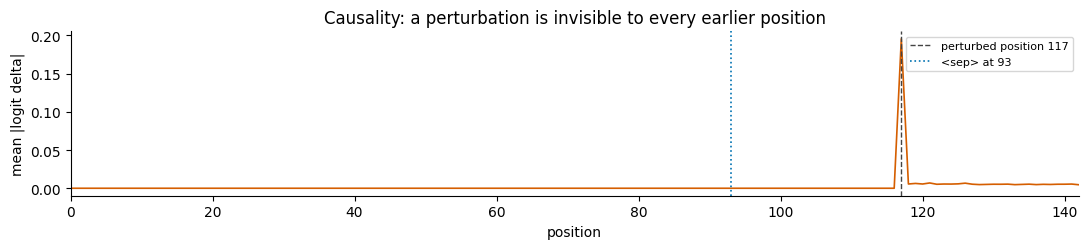

In [10]:
model.eval()
row = ids[:1].clone()
row_mask = masks[:1]
n0, s0 = int(row_mask.sum()), int(sep[0])

with torch.no_grad():
    base = model.deducer(row, row_mask)[0]

# (a) causality: perturb a mid-target position, look at where the change appears
j = (s0 + n0) // 2
bumped = row.clone(); bumped[0, j] = (int(row[0, j]) + 37) % model.deducer.vocab_size
with torch.no_grad():
    after = model.deducer(bumped, row_mask)[0]
delta = (after - base).abs().mean(dim=-1)

print('perturbed position %d of %d' % (j, n0))
print('  max |delta| BEFORE it (positions < %d): %.3e   <- must be 0' % (j, delta[:j].max()))
print('  max |delta| AT/AFTER  (positions >= %d): %.3e' % (j, delta[j:].max()))
assert delta[:j].max() == 0, 'future token leaked into an earlier position'
assert delta[j:].max() > 0, 'perturbation had no effect at all — is the input reaching the stack?'

# (b) conditioning: perturb the SOURCE, measure the target region
k = s0 // 2
src_bumped = row.clone(); src_bumped[0, k] = (int(row[0, k]) + 37) % model.deducer.vocab_size
with torch.no_grad():
    src_after = model.deducer(src_bumped, row_mask)[0]
tgt_shift = (src_after - base).abs()[s0:n0].mean().item()
print('\nperturbing source position %d changes the target logits by %.3e (mean |delta|)' % (k, tgt_shift))
print('  source is genuinely conditioning:', tgt_shift > 0)
assert tgt_shift > 0, 'the target half does not depend on the source — translation is not happening'

fig, ax = plt.subplots(figsize=(11, 2.6))
ax.plot(delta.numpy(), color=C_TGT, lw=1.2)
ax.axvline(j, color='#444444', ls='--', lw=1, label=f'perturbed position {j}')
ax.axvline(s0, color=C_SRC, ls=':', lw=1.2, label=f'<sep> at {s0}')
ax.set_xlim(0, n0)
ax.set_xlabel('position'); ax.set_ylabel('mean |logit delta|')
ax.set_title('Causality: a perturbation is invisible to every earlier position')
ax.legend(fontsize=8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

### 4a. The visibility matrix, measured rather than drawn

Section 4 proves causality at one perturbed position. This maps the whole thing: for every key
position `j`, perturb `input_ids[:, j]` and record which query positions `i` move. Cell `[i, j]` lit
means *`i` can see `j`* — so this is the attention mask the stack **actually** applies, recovered from
its outputs, not a picture of the mask we believe we passed.

Two perturbation offsets are tried per column and the effects OR'd together, because a single
substitution can land on a token whose embedding happens to leave one position numerically unmoved.

The three properties to read off it, all asserted below:

- **Lower-triangular** over the real region — nothing sees its own future. This is what makes teacher
  forcing honest.
- **Every target query sees every source key** (the whole block left of the `<sep>` column is lit for
  target rows). That is the translation channel; if this block were dark the model would be an
  unconditional LM, and section 4's single sensitivity number would be the only thing standing between
  that and a healthy-looking loss curve.
- **Padding columns are dark** for every real query. Right-padding cannot reach back into content.

A short synthetic row is used — 12 source tokens, `<sep>`, 10 target tokens, 6 pad — because this
costs one forward pass per column, and it is assembled from a real sample's tokens rather than random
ids.

In [11]:
# Recover the applied attention mask empirically: perturb each key column, see which queries move.
model.eval()
S_SRC, S_TGT, S_PAD = 12, 10, 6

_case = val.describe(val.indices[0])
_full = torch.tensor(_case['ids'], dtype=torch.long)
demo_ids = torch.cat([
    _full[:S_SRC],                                              # source context
    torch.tensor([tok.sep_id]),                                 # the boundary
    _full[_case['sep'] + 1: _case['sep'] + 1 + S_TGT],          # target
    torch.full((S_PAD,), tok.pad_id, dtype=torch.long),         # right padding
]).unsqueeze(0)
T_d = demo_ids.shape[1]
n_real = S_SRC + 1 + S_TGT
sep_d = S_SRC
demo_mask = torch.zeros(1, T_d, dtype=torch.long); demo_mask[0, :n_real] = 1

with torch.no_grad():
    base_d = model.deducer(demo_ids, demo_mask)[0]

# Two offsets OR'd: one substitution might leave a position numerically unmoved by chance.
vis = np.zeros((T_d, T_d))
for j in range(T_d):
    moved = torch.zeros(T_d)
    for off in (37, 211):
        bumped = demo_ids.clone()
        bumped[0, j] = (int(demo_ids[0, j]) + off) % model.deducer.vocab_size
        with torch.no_grad():
            out_d = model.deducer(bumped, demo_mask)[0]
        moved = torch.maximum(moved, (out_d - base_d).abs().mean(dim=-1))
    vis[:, j] = (moved > 1e-7).numpy()

# The mask we would draw by hand, for comparison.
qi, kj = np.arange(T_d)[:, None], np.arange(T_d)[None, :]
real = (demo_mask[0].numpy() == 1)
theory = ((kj <= qi) & real[None, :] & real[:, None]).astype(float)

tri_leak = vis[np.triu_indices(n_real, 1)].sum()
pad_leak = vis[:n_real, n_real:].sum()
cross = vis[sep_d + 1:n_real, :sep_d + 1]
print('empirical mask == hand-drawn causal mask (real block):',
      np.array_equal(vis[:n_real, :n_real], theory[:n_real, :n_real]))
print('future leaks (above the diagonal)                   :', int(tri_leak), '  <- must be 0')
print('pad columns reaching a real query                   :', int(pad_leak), '  <- must be 0')
print('target queries seeing every source key              :', bool(cross.all()),
      '(%d/%d cells lit)' % (int(cross.sum()), cross.size))
assert tri_leak == 0, 'a query attended to its own future'
assert pad_leak == 0, 'padding influenced a real position'
assert cross.all(), 'a target position cannot see part of the source — the translation channel is broken'
assert np.array_equal(vis[:n_real, :n_real], theory[:n_real, :n_real])

empirical mask == hand-drawn causal mask (real block): True
future leaks (above the diagonal)                   : 0   <- must be 0
pad columns reaching a real query                   : 0   <- must be 0
target queries seeing every source key              : True (130/130 cells lit)


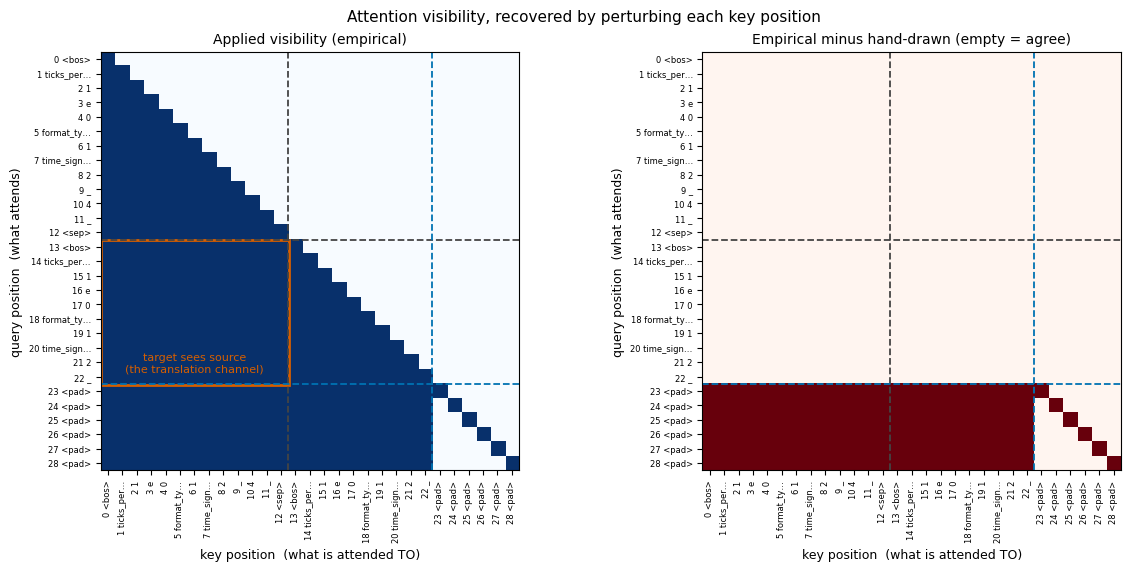

regions: source 0-11 | <sep> 12 | target 13-22 | padding 23-28


In [12]:
# Left: what the stack applies. Right: the difference against the hand-drawn mask (empty = agreement).
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6), layout='constrained')

labels = [tok.tokens[int(i)] for i in demo_ids[0]]
tick_lab = ['%d %s' % (i, l if len(l) <= 10 else l[:9] + '\u2026') for i, l in enumerate(labels)]

for ax, mat, title, cmap in (
        (axes[0], vis, 'Applied visibility (empirical)', 'Blues'),
        (axes[1], np.abs(vis - theory), 'Empirical minus hand-drawn (empty = agree)', 'Reds')):
    ax.imshow(mat, cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
    ax.set_xticks(range(T_d)); ax.set_yticks(range(T_d))
    ax.set_xticklabels(tick_lab, rotation=90, fontsize=6)
    ax.set_yticklabels(tick_lab, fontsize=6)
    ax.set_xlabel('key position  (what is attended TO)', fontsize=9)
    ax.set_ylabel('query position  (what attends)', fontsize=9)
    ax.set_title(title, fontsize=10)
    # region boundaries: the <sep> line, and where padding starts.
    ax.axvline(sep_d + 0.5, color='#444444', lw=1.3, ls='--')
    ax.axhline(sep_d + 0.5, color='#444444', lw=1.3, ls='--')
    ax.axvline(n_real - 0.5, color=C_SRC, lw=1.3, ls='--')
    ax.axhline(n_real - 0.5, color=C_SRC, lw=1.3, ls='--')
    ax.set_xlim(-0.5, T_d - 0.5); ax.set_ylim(T_d - 0.5, -0.5)

# Name the one block that carries the translation: target queries x source keys.
axes[0].add_patch(plt.Rectangle((-0.45, sep_d + 0.55), sep_d + 1, n_real - sep_d - 1,
                                fill=False, edgecolor=C_TGT, lw=2))
axes[0].text(sep_d / 2, n_real - 1.2, 'target sees source\n(the translation channel)',
             color=C_TGT, fontsize=8, ha='center', va='bottom')

fig.suptitle('Attention visibility, recovered by perturbing each key position', fontsize=11)
plt.show()

print('regions: source 0-%d | <sep> %d | target %d-%d | padding %d-%d'
      % (sep_d - 1, sep_d, sep_d + 1, n_real - 1, n_real, T_d - 1))

## 5. Padding invariance

Right-padding a batch must not change any row's loss. `target_mask` already excludes the pad tail, and
the stack is causal, so this should hold twice over — but batching is exactly where a mask bug hides,
and the symptom would be a loss that drifts with whatever else happens to be in the batch.

In [13]:
def pad_to(b, extra):
    '''Extend the pad tail. position_ids must CONTINUE each row's run, not take a zero fill -- a
    constant would drop a real position onto a pad slot and break the arithmetic run, which RoPE
    applies before the attention mask drops the slot. This mirrors what collateBatch does.'''
    z = lambda t: torch.cat([t, torch.zeros(t.shape[0], extra, dtype=t.dtype)], dim=1)
    grow = torch.stack([p[-1] + torch.arange(1, extra + 1) for p in b['position_ids']])
    return dict(input_ids=z(b['input_ids']), masks=z(b['masks']), target_mask=z(b['target_mask']),
                position_ids=torch.cat([b['position_ids'], grow], dim=1))

model.eval()
with torch.no_grad():
    l_plain, _ = model(batch)
    l_padded, _ = model(pad_to(batch, 64))

    # And row 0 alone must give the same loss as row 0 inside the batch.
    solo = {k: v[:1] for k, v in batch.items() if k != 'sep_index'}
    l_solo, _ = model(solo)
    per_row = []
    for r in range(len(ids)):
        one = {k: v[r:r + 1] for k, v in batch.items() if k != 'sep_index'}
        l_one, _ = model(one)
        per_row.append(l_one.item())

print('loss, batch           : %.8f' % l_plain.item())
print('loss, + 64 pad columns: %.8f   delta %.2e' % (l_padded.item(), abs(l_plain.item() - l_padded.item())))
print('loss, row 0 alone     : %.8f   vs %.8f in-batch-row-0' % (l_solo.item(), per_row[0]))
assert abs(l_plain.item() - l_padded.item()) < 1e-5, 'padding changed the loss'

# The batch loss is a token-weighted mean over supervised positions, so it must equal the per-row
# losses weighted by their target lengths — not their plain average.
w = tmask.sum(dim=1).float()
weighted = float((torch.tensor(per_row) * w).sum() / w.sum())
print('\nper-row losses        :', ['%.4f' % x for x in per_row])
print('target lengths        :', w.long().tolist())
print('token-weighted mean   : %.8f   (batch loss %.8f)' % (weighted, l_plain.item()))
print('plain mean            : %.8f   <- NOT what the batch loss is' % (sum(per_row) / len(per_row)))
assert abs(weighted - l_plain.item()) < 1e-4

loss, batch           : 6.74410820
loss, + 64 pad columns: 6.74410820   delta 0.00e+00
loss, row 0 alone     : 6.83084726   vs 6.83084726 in-batch-row-0

per-row losses        : ['6.8308', '6.7206', '6.7484']
target lengths        : [48, 222, 244]
token-weighted mean   : 6.74410725   (batch loss 6.74410820)
plain mean            : 6.76662699   <- NOT what the batch loss is


## 6. Loss, metrics, and `stat()` folding

`forward` returns `(loss, metrics)` — the trainer's whole step, there is no `training_step`. The metric
dict differs by mode on purpose: the per-token-type errors are computed only under `if not
self.training`, so a train epoch stays cheap. `stat()` therefore has to tolerate a changing key set,
and it folds every `err_*` into ONE `error` dict so TensorBoard renders a single `error/*` panel
instead of one panel per token type.

The types come from `_build_type_map`, which classifies each vocab id by its **token string** against
the same `assets/midiseq2Vocab.yaml` the feeder reads — so the partition tracks the asset rather than
hardcoding ids. `special` and `sep` get class codes but are deliberately not reported.

A type absent from the batch gets `WeightedValue` weight 0 and is dropped rather than logged as an
`inf` — worth seeing, since `channel` is essentially always absent in this corpus.

In [14]:
model.train()
loss_tr, m_tr = model(batch)
model.eval()
with torch.no_grad():
    loss_ev, m_ev = model(batch)

print('TRAIN keys:', sorted(m_tr.keys()))
print('EVAL  keys:', sorted(m_ev.keys()))
print('\nreturn is a 2-tuple of (scalar, dict):',
      loss_tr.dim() == 0 and isinstance(m_tr, dict))
print('loss is finite:', bool(torch.isfinite(loss_tr)))

# Random init over 838 classes: CE should sit near ln(838).
print('\nloss %.4f vs ln(vocab) = %.4f  (random-init sanity)' % (loss_ev.item(), np.log(838)))

# stat() as the trainer calls it, with grad_norm injected the way trainer.py does on the train path.
acc_tr = m_tr['acc']
print('\nacc is a WeightedValue:', isinstance(acc_tr, WeightedValue), '->', acc_tr)
print('   weight == supervised token count:', acc_tr.weight == int(tmask.sum()))

print('\nstat(train + grad_norm, n_batch=1):')
for k, v in model.stat({**m_tr, 'grad_norm': 1.5}, 1).items():
    print('   %-10s %s' % (k, v))
print('\nstat(eval, n_batch=1):')
stat_ev = model.stat(dict(m_ev), 1)
for k, v in stat_ev.items():
    print('   %-10s %s' % (k, v))

absent = [k for k, v in m_ev.items() if isinstance(v, WeightedValue) and v.weight == 0]
print('\ntypes absent from this batch (weight 0, dropped by stat):', [k[4:] for k in absent])
assert not any(k[4:] in stat_ev.get('error', {}) for k in absent), 'a zero-weight type leaked into error/'
assert 'error' in stat_ev and 'error' not in model.stat({**m_tr, 'grad_norm': 1.5}, 1)

TRAIN keys: ['acc', 'err']
EVAL  keys: ['acc', 'err', 'err_channel', 'err_elapse', 'err_nibble', 'err_pitch', 'err_type', 'err_vel']

return is a 2-tuple of (scalar, dict): True
loss is finite: True

loss 6.7441 vs ln(vocab) = 6.7310  (random-init sanity)

acc is a WeightedValue: True -> 0.0 (*514)
   weight == supervised token count: True

stat(train + grad_norm, n_batch=1):
   acc        0.0
   err        1.0
   grad_norm  1.5

stat(eval, n_batch=1):
   acc        0.0
   err        1.0
   error      {'type': 1.0, 'elapse': 1.0, 'channel': 1.0, 'pitch': 1.0, 'vel': 1.0, 'nibble': 1.0}

types absent from this batch (weight 0, dropped by stat): []


supervised target tokens: 514

type         count   share  error
type           138   26.8%  1.000
pitch          127   24.7%  1.000
channel        107   20.8%  1.000
vel             64   12.5%  1.000
nibble          33    6.4%  1.000
elapse          29    5.6%  1.000
special          8    1.6%  not reported
sep              8    1.6%  not reported


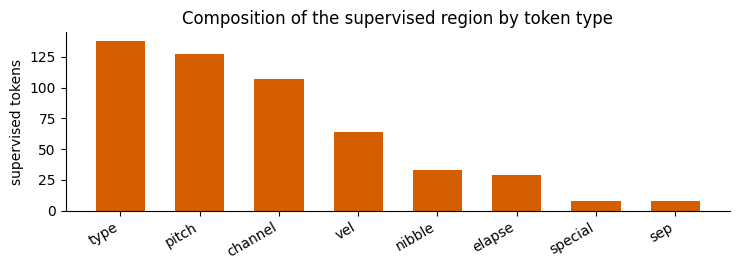

In [15]:
# What the supervised region is actually MADE of, per token type. The error panel is only readable
# against this: a type that is 2% of the targets cannot move the headline accuracy much, however
# badly it does.
from starry.midi.models.midiSeq2BgptSelfAttn import _TYPE_CODES

code_name = {c: n for n, c in _TYPE_CODES.items()}
cls = model.type_of_id[labels_r]
counts = [(code_name[c], int((cls == c).sum())) for c in sorted(code_name)]
counts = [(n, c) for n, c in counts if c > 0]
total = sum(c for _, c in counts)

print('supervised target tokens: %d\n' % total)
print('%-10s %7s %7s  %s' % ('type', 'count', 'share', 'error'))
err = stat_ev.get('error', {})
for n, c in sorted(counts, key=lambda x: -x[1]):
    e = ('%.3f' % err[n]) if n in err else ('not reported' if n in ('special', 'sep') else '-')
    print('%-10s %7d %6.1f%%  %s' % (n, c, 100 * c / total, e))

fig, ax = plt.subplots(figsize=(7.5, 2.8))
names = [n for n, _ in sorted(counts, key=lambda x: -x[1])]
vals = [c for _, c in sorted(counts, key=lambda x: -x[1])]
ax.bar(range(len(names)), vals, color=C_TGT, width=0.62)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=30, ha='right')
ax.set_ylabel('supervised tokens')
ax.set_title('Composition of the supervised region by token type')
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

In [16]:
# loss_type_weights: uniform weights must reproduce plain cross-entropy EXACTLY (so the weighted path
# is a strict generalization), and an unknown type name must raise rather than be silently ignored.
import torch.nn.functional as F

plain = F.cross_entropy(pred_r, labels_r).item()
print('plain cross_entropy        : %.8f' % plain)
print('model._loss (unweighted)   : %.8f' % model._loss(pred_r, labels_r).item())
print('weighted_loss flag         :', model.weighted_loss, '(uniform -> False, so CE is used directly)')
assert abs(model._loss(pred_r, labels_r).item() - plain) < 1e-6

w_model = loadModel({'type': config['model.type'],
                     'args': {**small, 'loss_type_weights': {'elapse': 1.0, 'pitch': 1.0}}},
                    postfix='Loss', imports=config['imports'])
print('\nall-1.0 weights -> weighted_loss:', w_model.weighted_loss, '(no overhead when nothing deviates)')

w2 = loadModel({'type': config['model.type'], 'args': {**small, 'loss_type_weights': {'elapse': 2.0}}},
               postfix='Loss', imports=config['imports'])
print('elapse 2.0      -> weighted_loss:', w2.weighted_loss,
      '| ce_weight of an elapse id:', float(w2.ce_weight_of_id[w2.type_of_id == _TYPE_CODES['elapse']][0]))

try:
    loadModel({'type': config['model.type'], 'args': {**small, 'loss_type_weights': {'tempo': 2.0}}},
              postfix='Loss', imports=config['imports'])
    print('\nFAIL: an unknown token-type name was accepted')
except ValueError as e:
    print('\nunknown type name raises:', str(e)[:70])

try:
    loadModel({'type': config['model.type'], 'args': {**small, 'backbone': 'mamba'}},
              postfix='Loss', imports=config['imports'])
    print('FAIL: an unsupported backbone was accepted')
except ValueError as e:
    print('unsupported backbone raises:', str(e)[:70])

plain cross_entropy        : 6.74503279
model._loss (unweighted)   : 6.74503279
weighted_loss flag         : False (uniform -> False, so CE is used directly)

all-1.0 weights -> weighted_loss: False (no overhead when nothing deviates)
elapse 2.0      -> weighted_loss: True | ce_weight of an elapse id: 2.0

unknown type name raises: unknown loss_type_weights key 'tempo'; valid: ['channel', 'elapse', 'n
unsupported backbone raises: unknown backbone 'mamba'; supported: llama


In [17]:
# Checkpointing contract: the trainer saves ONLY model.deducer.state_dict(), so anything the wrapper
# owns must either live inside deducer or be a persistent=False buffer, or it silently vanishes on
# resume. Both type maps here are derived from the vocab asset, never learned.
wrapper_only = [n for n, _ in model.named_parameters() if not n.startswith('deducer.')]
saved = model.deducer.state_dict()
print('trainable params outside deducer:', wrapper_only, '(must be empty)')
print('deducer.state_dict tensors      :', len(saved))
print('wrapper buffers, non-persistent :',
      [n for n, _ in model.named_buffers() if not n.startswith('deducer.')])
print('   ... absent from any state_dict:',
      [n for n in ('type_of_id', 'ce_weight_of_id') if n not in model.state_dict()])
assert not wrapper_only

# Round-trip: the saved dict must load back into a freshly built deducer.
fresh = loadModel({'type': config['model.type'], 'args': small},
                  postfix='Loss', imports=config['imports'])
missing, unexpected = fresh.deducer.load_state_dict(saved, strict=True), None
print('\nstate_dict round-trips into a fresh deducer:', missing)
print('training_parameters  :', len(model.training_parameters()), 'tensors')
print('validation_parameters:', len(model.validation_parameters()), 'tensors (trainDist.py contract)')

trainable params outside deducer: [] (must be empty)
deducer.state_dict tensors      : 21
wrapper buffers, non-persistent : ['type_of_id', 'ce_weight_of_id']
   ... absent from any state_dict: ['type_of_id', 'ce_weight_of_id']

state_dict round-trips into a fresh deducer: <All keys matched successfully>
training_parameters  : 22 tensors
validation_parameters: 0 tensors (trainDist.py contract)


## 7. Overfit one batch

The end-to-end gradient check: loss must fall toward 0 and accuracy reach 1 on a single batch. This
says the shift, the mask and the backprop path agree — it says nothing about generalization, which is
why the panels below are on separate scales and none is labelled a metric.

Measured at this small size and lr 1.5e-3: accuracy crosses 0.9 at step ~71 and 0.95 at ~87, so the
150 steps below leave margin without being slow. A larger model gets there sooner.

step  0: loss 6.7708  acc 0.000
step 149: loss 0.0389  acc 0.994


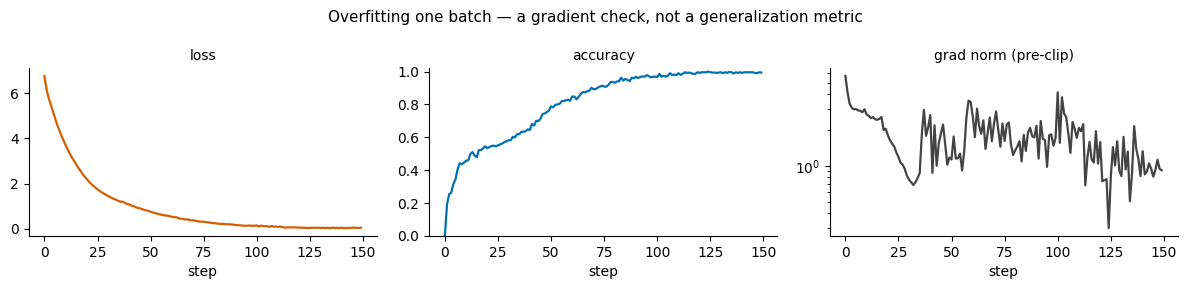

In [18]:
over = loadModel({'type': config['model.type'], 'args': small}, postfix='Loss', imports=config['imports'])
over.train()
opt = torch.optim.Adam(over.parameters(), lr=1.5e-3)
history = []
for step in range(150):
    opt.zero_grad()
    loss, metric = over(batch)
    loss.backward()
    gn = torch.nn.utils.clip_grad_norm_([p for p in over.parameters() if p.requires_grad], float('inf'))
    opt.step()
    history.append((loss.item(), metric['acc'].value, float(gn)))

print('step  0: loss %.4f  acc %.3f' % (history[0][0], history[0][1]))
print('step 149: loss %.4f  acc %.3f' % (history[-1][0], history[-1][1]))
assert history[-1][0] < history[0][0] * 0.05, 'loss did not fall — the gradient path is broken'
assert history[-1][1] > 0.95, 'accuracy did not reach the batch'

fig, axes = plt.subplots(1, 3, figsize=(12, 2.9))
for ax, idx, label, color in ((axes[0], 0, 'loss', C_TGT), (axes[1], 1, 'accuracy', C_SRC),
                              (axes[2], 2, 'grad norm (pre-clip)', '#444444')):
    ax.plot([h[idx] for h in history], color=color, lw=1.6)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel('step')
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
axes[1].set_ylim(0, 1.02)
axes[2].set_yscale('log')
fig.suptitle('Overfitting one batch — a gradient check, not a generalization metric', fontsize=11)
plt.tight_layout(); plt.show()

## 8. Free-run generation from a real source half

`deducer.generate` continues a prefix — the source half plus `<sep>` (plus `<bos>` when the crop
reached the start of the piece, matching what the feeder puts on the target). It stops at `<eos>`.

The batch-overfitted model from section 7 is used, so this shows the *mechanism* working on a prefix
it has memorized; an untrained model emits noise and never stops. What to read here is that the
prefix is assembled correctly and termination happens at all — the `<eos>` inside `target_mask` is
what makes stopping learnable in the first place.

One indexing trap worth naming: `describe(i)` takes a **corpus file index**, while `__getitem__(i)`
maps through `self.indices` (the split filter). So the sample behind batch row 0 is
`describe(val.indices[0])`, not `describe(0)` — the latter is a different piece entirely, and using it
here would mean generating from a prefix this model never saw while the surrounding prose claimed
otherwise. The assertion below pins the two together.

There is no KV cache: the whole prefix is recomputed per token, O(T²) per step. Fine for a notebook,
not for bulk decoding.

In [19]:
# describe() indexes the CORPUS; __getitem__ indexes the SPLIT. Row 0 of the batch is therefore
# val.indices[0], and the assertion makes sure this is the very sequence section 7 overfitted.
case = val.describe(val.indices[0])
row_ids = torch.tensor(case['ids'], dtype=torch.long)
s = case['sep']
n0_row = int(masks[0].sum())
assert torch.equal(row_ids, ids[0, :n0_row]), 'describe() returned a different sample than batch row 0'
assert s == int(sep[0])

# Prefix = source half ++ <sep> ++ (<bos> if the crop reached the start, as the feeder does).
prefix = row_ids[:s + 1]
if case['head']:
    prefix = torch.cat([prefix, torch.tensor([tok.bos_id])])
truth = row_ids[len(prefix):]

over.eval()
gen = over.deducer.generate(prefix, max_new_tokens=min(400, len(truth) + 40),
                            eos_id=tok.eos_id, temperature=0.0)

print('sample     :', case['name'])
print('crop       : head', case['head'], '| tail', case['tail'],
      '| source lines', case['source_range'], '-> target lines', case['target_range'])
print('prefix     : %d tokens (source %d + <sep>%s)' % (
    len(prefix), s, ' + <bos>' if case['head'] else ''))
print('reference  : %d tokens | generated: %d tokens' % (len(truth), len(gen)))
print('stopped at <eos>:', int(gen[-1]) == tok.eos_id if len(gen) else False)

n_cmp = min(len(gen), len(truth))
match = int((gen[:n_cmp] == truth[:n_cmp]).sum())
print('prefix-aligned token match: %d/%d (%.1f%%)' % (match, n_cmp, 100 * match / max(1, n_cmp)))

print('\nfirst 24 tokens')
print('  reference:', ' '.join(tok.tokens[int(i)] for i in truth[:24]))
print('  generated:', ' '.join(tok.tokens[int(i)] for i in gen[:24]))

sample     : 0000d32362fe8ce09e3729147f12996f.midiseq2.txt
crop       : head True | tail False | source lines (0, 39) -> target lines (0, 18)
prefix     : 95 tokens (source 93 + <sep> + <bos>)
reference  : 47 tokens | generated: 28 tokens
stopped at <eos>: True
prefix-aligned token match: 1/28 (3.6%)

first 24 tokens
  reference: ticks_per_beat 1 e 0 format_type 1 time_signature 2 _ 4 _ 1 8 _ 8 key_signature 2 _ 0 set_tempo 9 b d 5
  generated: ticks_per_beat #2f note_on C2 #36 note_on #2f note_on #2f note_on #4d note_off #36 note_on #4d note_off #42 $50 note_on #4d note_off #42 $50 E070


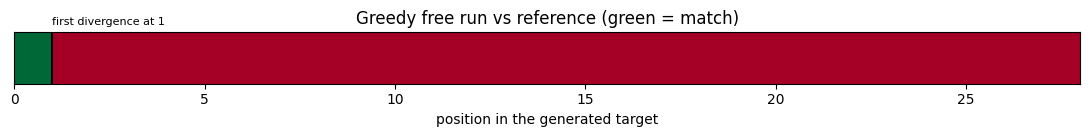

agreement 3.6% over 28 compared positions | first divergence at 1


In [20]:
# Where the free run diverges from the reference. Greedy decoding is self-feeding, so the first
# mismatch is what matters — everything after it is conditioned on a token the reference never had.
agree = (gen[:n_cmp] == truth[:n_cmp]).numpy()
first_bad = int(np.argmin(agree)) if not agree.all() else n_cmp

fig, ax = plt.subplots(figsize=(11, 1.5))
ax.imshow(agree.reshape(1, -1), aspect='auto', cmap='RdYlGn', vmin=0, vmax=1,
          extent=[0, n_cmp, 0, 1])
if first_bad < n_cmp:
    ax.axvline(first_bad, color='#000000', lw=1.4)
    ax.text(first_bad, 1.15, f'first divergence at {first_bad}', fontsize=8, ha='left')
ax.set_yticks([])
ax.set_xlabel('position in the generated target')
ax.set_title('Greedy free run vs reference (green = match)')
plt.tight_layout(); plt.show()

print('agreement %.1f%% over %d compared positions | first divergence at %s' % (
    100 * agree.mean(), n_cmp, first_bad if first_bad < n_cmp else 'none'))

## What this validates, and what it does not

Validated here: the config loads through the trainer's own `loadModel(..., postfix='Loss')` path; the
batch's four tensors satisfy the invariants the loss depends on; the shift is exactly
`logits[:, i - 1] -> input_ids[:, i]` on the target region and nowhere else, checked position by
position on the real batch; the stack is causal — and the mask it actually applies, recovered column by column, is exactly the
hand-drawn one (lower-triangular, padding dark, every target position seeing every source position);
the source genuinely conditions the target; padding
and batching do not move the loss; the batch loss is the token-weighted (not per-row) mean; `stat()`
folds the per-type errors into one panel and drops absent types; uniform `loss_type_weights`
reproduces plain CE exactly; bad backbone / type names raise; the checkpoint contract holds (nothing
trainable outside `deducer`, non-persistent buffers, clean round-trip); one batch overfits; free-run
generation assembles its prefix correctly and terminates on `<eos>`.

Not validated here: anything about translation *quality*. The corpus behind this config is 99 samples
with a 9-sample val split — a smoke set. Its val curve is a sanity signal, not a metric to tune
against or compare runs on. And the free run above continues a prefix the model was deliberately
overfitted to, so its agreement number says nothing about a held-out piece.